In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv(r"C:\Users\rmstn\final_project\Geunsu\data\전처리완료_카드(가맹점).csv", encoding='utf-8')
df

,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,...,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt,mm_cnt_num
0,2023-01-01,41135,41135510,100470,Q13,음식,커피/음료,A,57,1,...,0,1,0,0,0,0,0,1,0,57
1,2023-01-01,41135,41135510,100470,R07,학문/교육,입시학원,A,84,1,...,0,1,0,0,0,0,0,0,1,84
2,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,A,1,1,...,1,0,1,0,0,1,0,0,0,1
3,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,E,32,1,...,0,0,1,0,0,1,0,0,0,32
4,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,신규,0,1,...,1,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2130066,2025-12-01,41135,41135670,99971,F02,생활서비스,미용서비스,A,6,1,...,0,1,0,1,0,0,0,0,0,6
2130067,2025-12-01,41135,41135670,99971,F06,생활서비스,세탁/가사서비스,A,199,1,...,0,0,0,0,0,0,0,0,1,199
2130068,2025-12-01,41135,41135670,99971,Q03,음식,닭/오리요리,A,166,1,...,0,0,0,0,0,0,0,0,1,166
2130069,2025-12-01,41135,41135670,99986,R03,학문/교육,기타교육,A,12,1,...,0,1,0,0,1,0,0,0,0,12


In [28]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 구명 매핑 (행정동 차트 가독성)
gu_map = {"41135": "분당구", "41133": "수정구", "41131": "중원구"}
df["구명"] = df["cty_rgn_no"].astype(str).map(gu_map)
df["구_행정동"] = df["구명"] + "_" + df["admi_cty_no"].astype(str)

# 매출구간 E 제외 (분석용)
df_eda = df[df["sale"] != "E"].copy()
df_eda["ta_ym"] = pd.to_datetime(df_eda["ta_ym"])

# 원도심(수정구,중원구) / 분당구 분리
df_원도심 = df_eda[df_eda["cty_rgn_no"].astype(str).isin(["41133", "41131"])].copy()
df_분당구 = df_eda[df_eda["cty_rgn_no"].astype(str) == "41135"].copy()

print(f"전체: {len(df):,}행  →  E 제외 후: {len(df_eda):,}행")
print(f"  원도심(수정+중원): {len(df_원도심):,}행")
print(f"  분당구(신도심):    {len(df_분당구):,}행")
print()
print("매출구간 분포 (E 제외):")
print(df_eda["sale"].value_counts())

전체: 2,130,071행  →  E 제외 후: 1,742,211행
  원도심(수정+중원): 898,306행
  분당구(신도심):    843,905행

매출구간 분포 (E 제외):
sale
A     1069467
B      231895
C      214109
D      159267
신규      67473
Name: count, dtype: int64


## 개폐업률 정의

| 지표 | 공식 |
|---|---|
| 개업률 (%) | Σ open_cnt / Σ mer_cnt × 100 |
| 폐업률 (%) | Σ close_cnt / Σ mer_cnt × 100 |

- 집계 단위별로 수량을 **합산한 뒤** 비율을 계산한다 (비율의 평균이 아님)
-  (30억 초과 또는 국세청 미등록) 제외

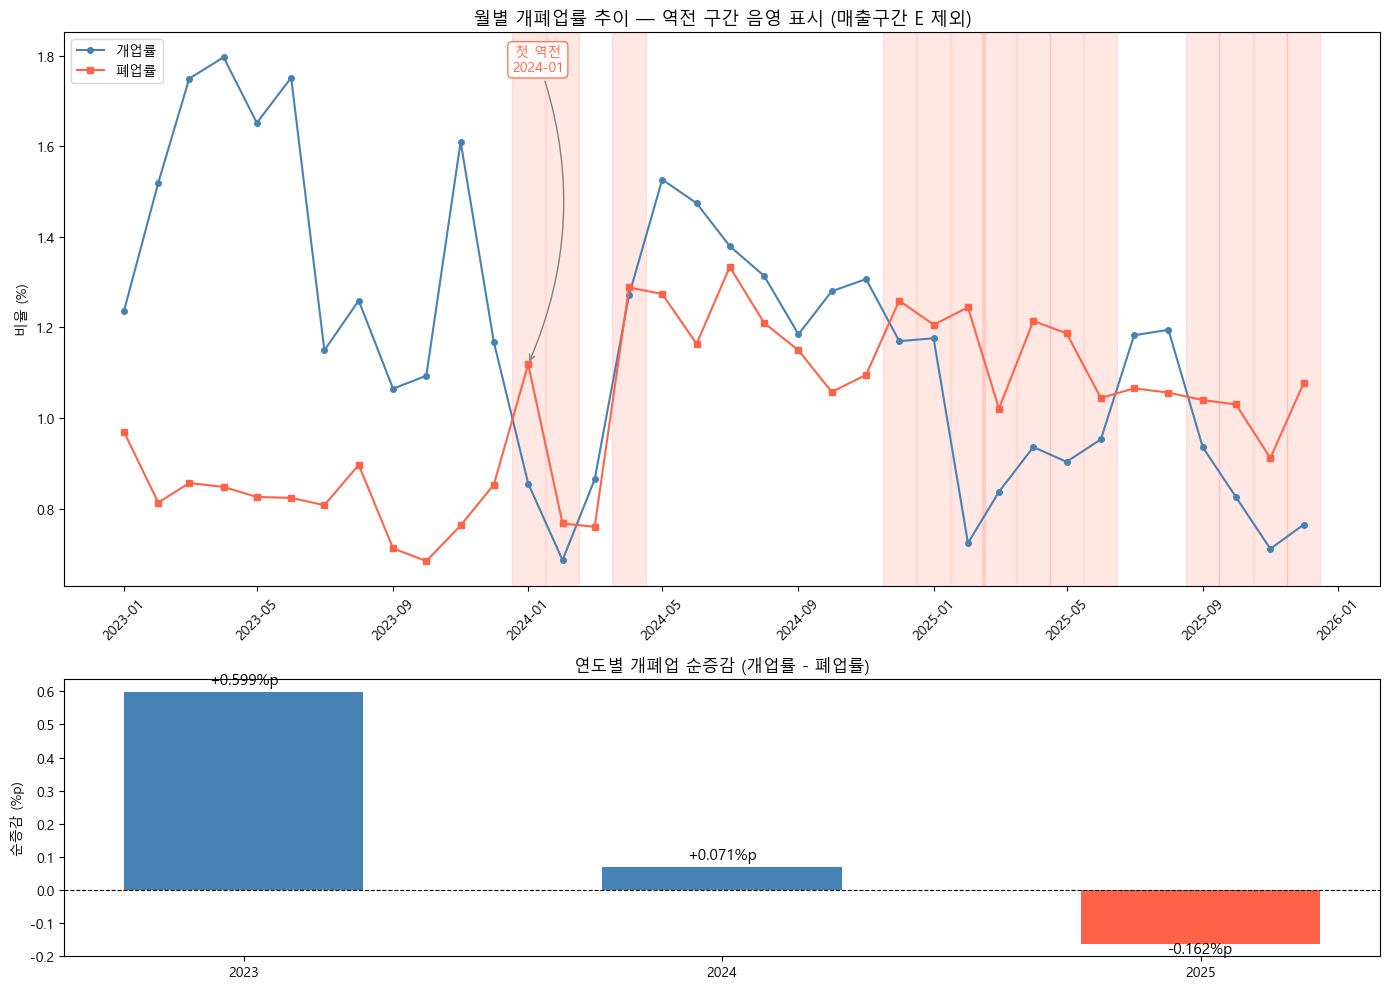

=== 연도별 개폐업률 요약 ===
         개업률    폐업률    순증감
ta_ym                     
2023   1.419  0.821  0.599
2024   1.195  1.124  0.071
2025   0.927  1.090 -0.162

역전 발생: 14개월 / 전체 36개월

=== 역전 구간 목록 (폐업률 > 개업률) ===
  ta_ym      개업률      폐업률       순증감
2024-01 0.855258 1.118608 -0.263349
2024-02 0.686163 0.767186 -0.081023
2024-04 1.270792 1.288183 -0.017391
2024-12 1.169549 1.259055 -0.089506
2025-01 1.176051 1.205779 -0.029728
2025-02 0.723858 1.244204 -0.520346
2025-03 0.837014 1.020501 -0.183486
2025-04 0.935880 1.214209 -0.278329
2025-05 0.903238 1.186947 -0.283709
2025-06 0.952744 1.044088 -0.091343
2025-09 0.935511 1.039578 -0.104067
2025-10 0.825229 1.029850 -0.204621
2025-11 0.711150 0.911616 -0.200466
2025-12 0.764287 1.076352 -0.312065


In [47]:
# ── 구조적 전환점 분석 ───────────────────────────────────────────
# 개업률 < 폐업률 역전 구간을 음영으로 표시하고, 연도별 순증감을 병행 시각화

monthly = (
    df_eda.groupby("ta_ym")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
monthly["개업률"] = monthly["open_cnt"] / monthly["mer_cnt"] * 100
monthly["폐업률"] = monthly["close_cnt"] / monthly["mer_cnt"] * 100

monthly["역전"] = monthly["폐업률"] > monthly["개업률"]
monthly["순증감"] = monthly["개업률"] - monthly["폐업률"]

# 연도별 집계
yearly = (
    df_eda.groupby(df_eda["ta_ym"].dt.year)[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
)
yearly["개업률"] = yearly["open_cnt"] / yearly["mer_cnt"] * 100
yearly["폐업률"] = yearly["close_cnt"] / yearly["mer_cnt"] * 100
yearly["순증감"] = yearly["개업률"] - yearly["폐업률"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1.5]})

# 상단: 월별 추이 + 역전 구간 음영 ────────────────────────────────────
ax = axes[0]
ax.plot(monthly["ta_ym"], monthly["개업률"], marker="o", ms=4, label="개업률", color="steelblue")
ax.plot(monthly["ta_ym"], monthly["폐업률"], marker="s", ms=4, label="폐업률", color="tomato")

for _, row in monthly[monthly["역전"]].iterrows():
    ax.axvspan(
        row["ta_ym"] - pd.Timedelta(days=15),
        row["ta_ym"] + pd.Timedelta(days=15),
        alpha=0.15, color="tomato",
    )

# 첫 역전 시점 주석 — 텍스트를 axes fraction(차트 상단)에 고정해 데이터와 겹침 방지
first_cross = monthly[monthly["역전"]].iloc[0]["ta_ym"]
y_arrow = monthly.loc[monthly["ta_ym"] == first_cross, "폐업률"].values[0]
ax.annotate(
    f"첫 역전\n{first_cross.strftime('%Y-%m')}",
    xy=(first_cross, y_arrow),
    xycoords="data",
    xytext=(0.36, 0.93),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="gray", connectionstyle="arc3,rad=-0.2"),
    fontsize=10, color="tomato", ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="tomato", alpha=0.85),
)

ax.set_title("월별 개폐업률 추이 — 역전 구간 음영 표시 (매출구간 E 제외)", fontsize=13)
ax.set_ylabel("비율 (%)")
ax.legend()
ax.tick_params(axis="x", rotation=45)

# 하단: 연도별 순증감 막대 ────────────────────────────────────────────
ax2 = axes[1]
bar_colors = ["steelblue" if v >= 0 else "tomato" for v in yearly["순증감"]]
bars = ax2.bar(yearly.index.astype(str), yearly["순증감"], color=bar_colors, width=0.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, v in zip(bars, yearly["순증감"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        v + (0.01 if v >= 0 else -0.04),
        f"{v:+.3f}%p",
        ha="center", va="bottom", fontsize=11,
    )
ax2.set_title("연도별 개폐업 순증감 (개업률 - 폐업률)", fontsize=12)
ax2.set_ylabel("순증감 (%p)")

plt.tight_layout()
plt.show()

# 수치 요약 출력
print("=== 연도별 개폐업률 요약 ===")
print(yearly[["개업률", "폐업률", "순증감"]].round(3).to_string())
print()
n_rev = monthly["역전"].sum()
print(f"역전 발생: {n_rev}개월 / 전체 {len(monthly)}개월")
print()
print("=== 역전 구간 목록 (폐업률 > 개업률) ===")
rev = monthly[monthly["역전"]][["ta_ym", "개업률", "폐업률", "순증감"]].copy()
rev["ta_ym"] = rev["ta_ym"].dt.strftime("%Y-%m")
print(rev.to_string(index=False))

# 그래프 해석

- 2024년 1월에 폐업률이 개업률을 역전한 첫번째 시점
- 전체 36개월중 14개월이 폐업률이 개업률을 상회하는 수치를 보임
- 2025년에는 12개월 중 10개월이 폐업률 우위로, 구조적 감소 국면에 진입함을 알 수 있음

---

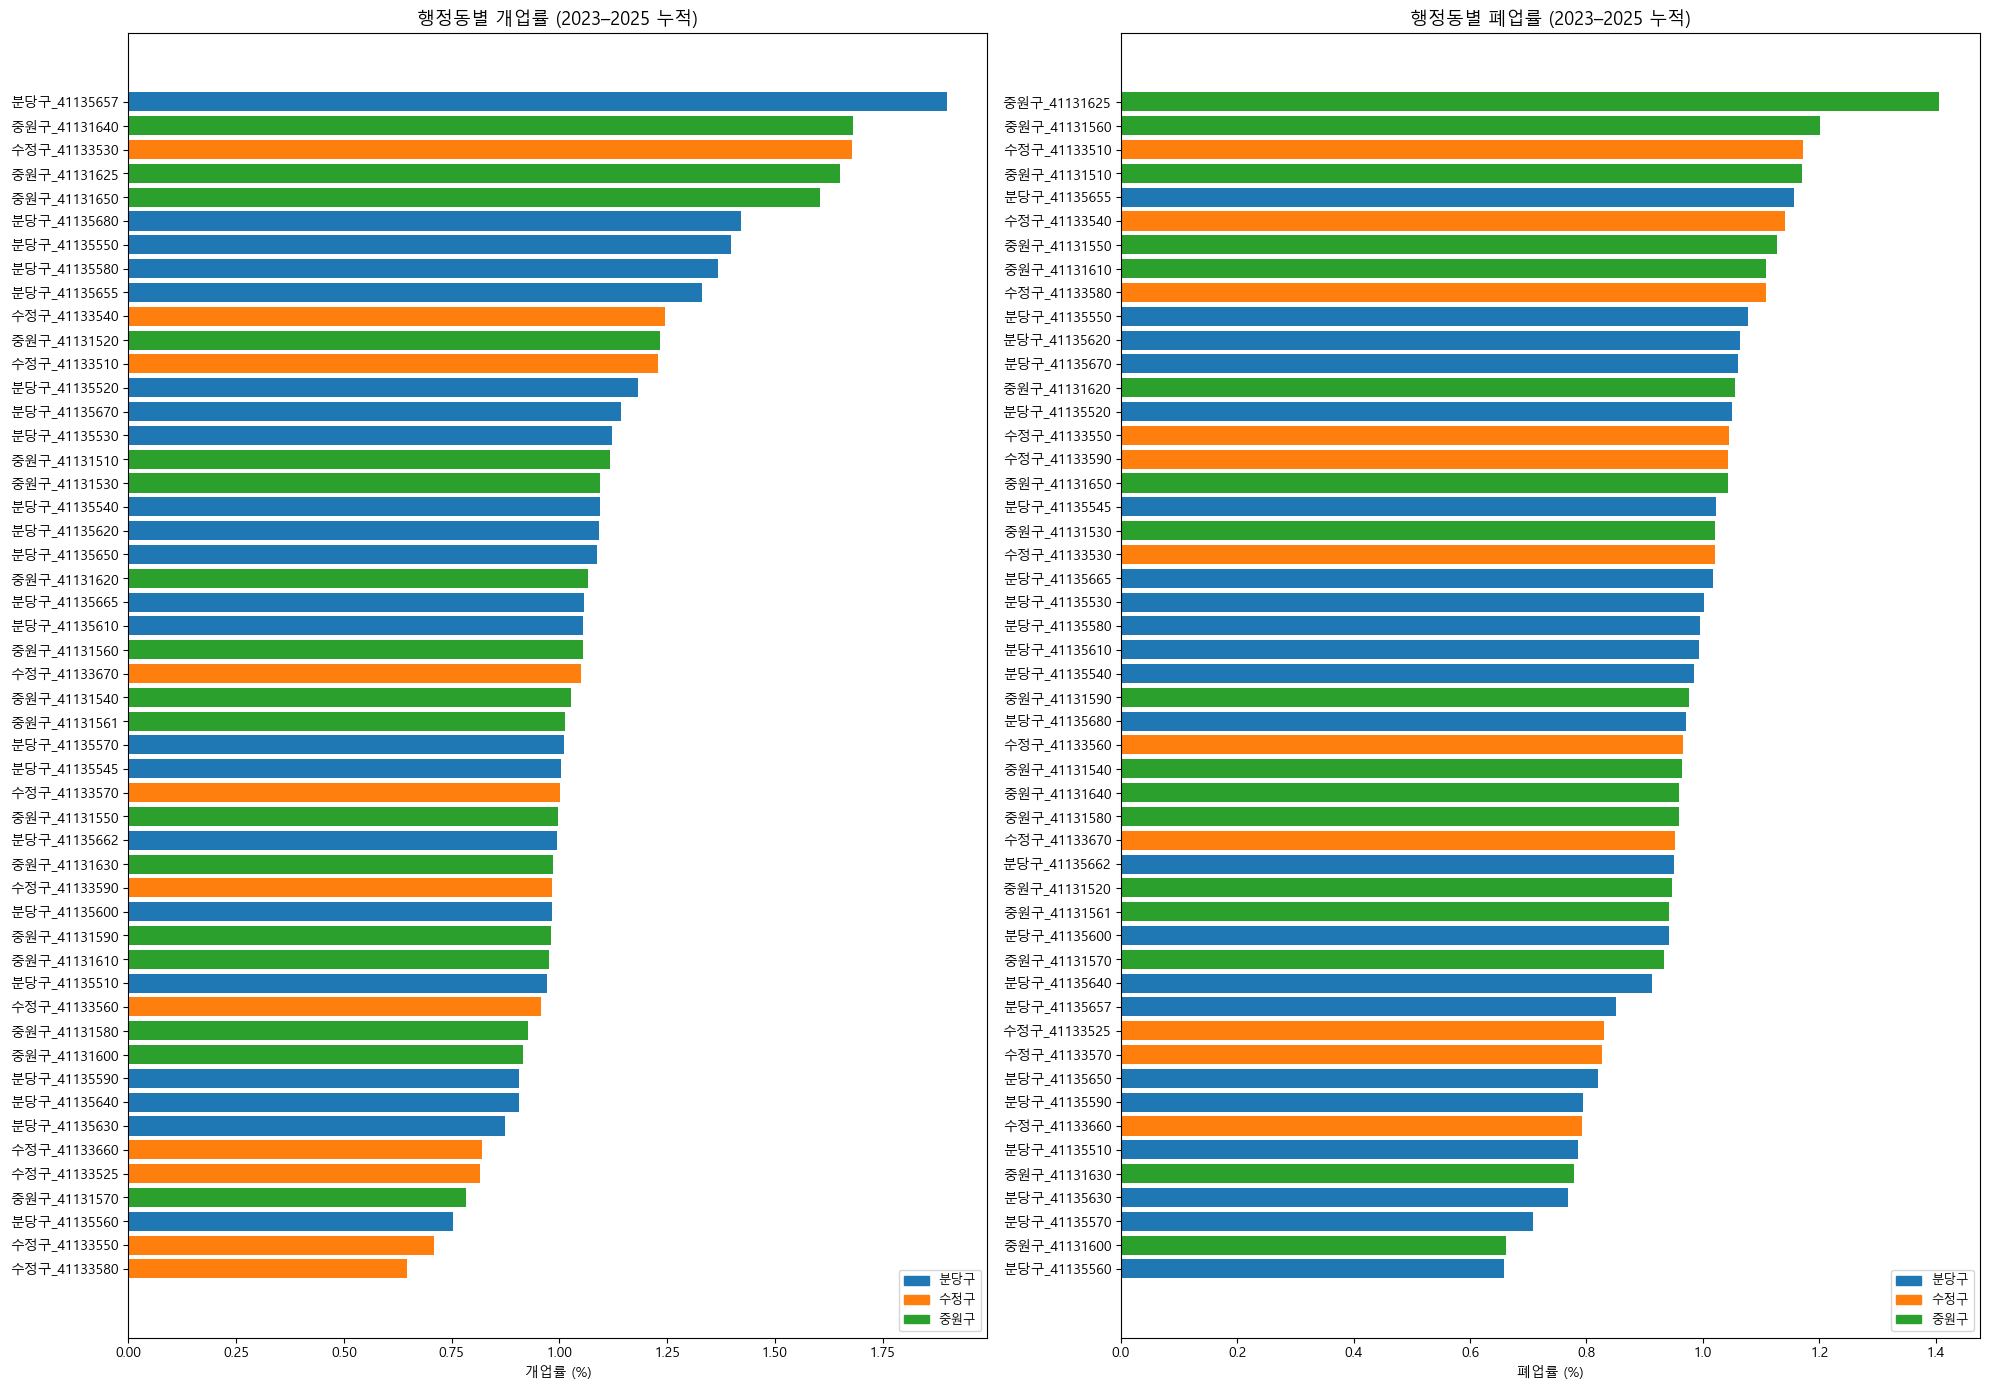

개업률 상위 5 행정동:
       구_행정동      개업률      폐업률
분당구_41135657 1.898202 0.850960
중원구_41131640 1.680176 0.959657
수정구_41133530 1.679766 1.020188
중원구_41131625 1.651286 1.405816
중원구_41131650 1.605207 1.042753

폐업률 상위 5 행정동:
       구_행정동      개업률      폐업률
중원구_41131625 1.651286 1.405816
중원구_41131560 1.054726 1.201493
수정구_41133510 1.228994 1.171784
중원구_41131510 1.116471 1.169637
분당구_41135655 1.331250 1.157052


In [ ]:
# ── 행정동별 개폐업률 (전체 기간 합산) ────────────────────────────
dong = (
    df_eda.groupby("구_행정동")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
dong["개업률"] = dong["open_cnt"] / dong["mer_cnt"] * 100
dong["폐업률"] = dong["close_cnt"] / dong["mer_cnt"] * 100

# 구별 색상 구분
color_map = {label: c for label, c in zip(
    dong["구_행정동"].str.split("_").str[0].unique(),
    ["#1f77b4", "#ff7f0e", "#2ca02c"]
)}
bar_colors_open  = dong.sort_values("개업률", ascending=True)["구_행정동"].str.split("_").str[0].map(color_map)
bar_colors_close = dong.sort_values("폐업률", ascending=True)["구_행정동"].str.split("_").str[0].map(color_map)

dong_open  = dong.sort_values("개업률", ascending=True)
dong_close = dong.sort_values("폐업률", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

axes[0].barh(dong_open["구_행정동"], dong_open["개업률"], color=bar_colors_open.values)
axes[0].set_title("행정동별 개업률 (2023–2025 누적)", fontsize=13)
axes[0].set_xlabel("개업률 (%)")

axes[1].barh(dong_close["구_행정동"], dong_close["폐업률"], color=bar_colors_close.values)
axes[1].set_title("행정동별 폐업률 (2023–2025 누적)", fontsize=13)
axes[1].set_xlabel("폐업률 (%)")

# 범례
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=g) for g, c in color_map.items()]
axes[0].legend(handles=legend_patches, loc="lower right", fontsize=9)
axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

print("개업률 상위 5 행정동:")
print(dong.nlargest(5, "개업률")[["구_행정동", "개업률", "폐업률"]].to_string(index=False))
print()
print("폐업률 상위 5 행정동:")
print(dong.nlargest(5, "폐업률")[["구_행정동", "개업률", "폐업률"]].to_string(index=False))

=== 구별 합산 개폐업률 (2023–2025 전체 기간) ===
 구명   개업률   폐업률   순증감
수정구 1.075 1.009 0.066
중원구 1.202 1.097 0.105
분당구 1.200 0.981 0.219
원도심 전체 행정동: 28개  /  폐업 우위(순증감<0): 11개 (39%)
  수정구: 5/11 행정동 폐업 우위
  중원구: 6/17 행정동 폐업 우위
순증감 하위 10 (폐업 우위 위험 지역) ---
       구_행정동   개업률   폐업률    순증감
수정구_41133580 0.648 1.108 -0.460
수정구_41133550 0.709 1.045 -0.336
중원구_41131570 0.784 0.933 -0.149
중원구_41131560 1.055 1.201 -0.147
중원구_41131610 0.976 1.109 -0.133
중원구_41131550 0.998 1.128 -0.130
수정구_41133590 0.983 1.044 -0.061
중원구_41131510 1.116 1.170 -0.053
중원구_41131580 0.927 0.959 -0.032
수정구_41133525 0.817 0.831 -0.014
--- 고회전 행정동 (개업률·폐업률 모두 상위 25% — 상권 불안정 교체 구간) ---
       구_행정동   개업률   폐업률   순증감
수정구_41133510 1.229 1.172 0.057
수정구_41133540 1.245 1.141 0.104
중원구_41131625 1.651 1.406 0.245


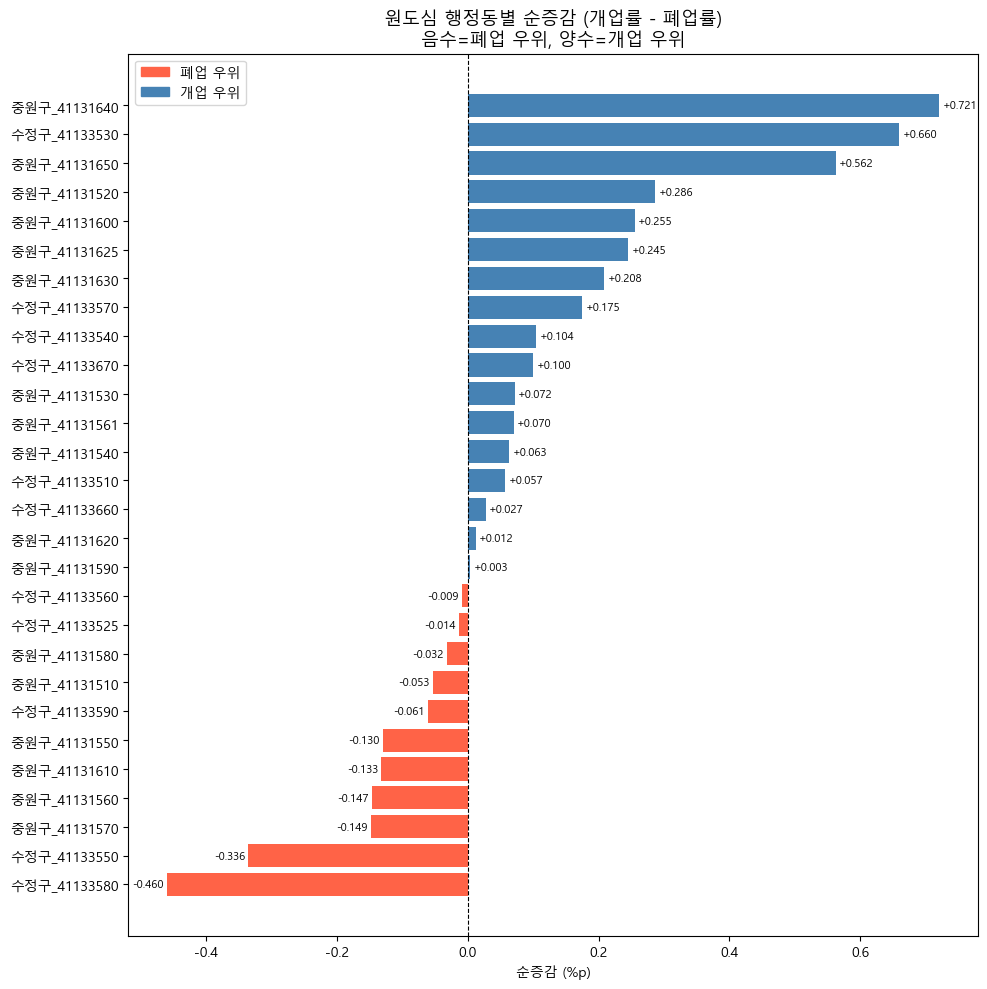

In [ ]:
dong["구명"]   = dong["구_행정동"].str.split("_").str[0]
dong["순증감"] = dong["개업률"] - dong["폐업률"]

# 1. 구별 합산 개폐업률 비교
구별 = (
    df_eda.groupby("구명")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
구별["개업률"] = 구별["open_cnt"] / 구별["mer_cnt"] * 100
구별["폐업률"] = 구별["close_cnt"] / 구별["mer_cnt"] * 100
구별["순증감"] = 구별["개업률"] - 구별["폐업률"]
print("=== 구별 합산 개폐업률 (2023–2025 전체 기간) ===")
print(구별[["구명","개업률","폐업률","순증감"]].sort_values("순증감").round(3).to_string(index=False))

# 2. 원도심 폐업 우위 행정동 현황
dong_원도심 = dong[dong["구명"].isin(["수정구", "중원구"])].copy()
n_neg = (dong_원도심["순증감"] < 0).sum()
print(f"원도심 전체 행정동: {len(dong_원도심)}개  /  폐업 우위(순증감<0): {n_neg}개 ({n_neg/len(dong_원도심)*100:.0f}%)")
for gu in ["수정구", "중원구"]:
    sub = dong_원도심[dong_원도심["구명"] == gu]
    neg = (sub["순증감"] < 0).sum()
    print(f"  {gu}: {neg}/{len(sub)} 행정동 폐업 우위")

print("순증감 하위 10 (폐업 우위 위험 지역) ---")
print(dong_원도심.nsmallest(10, "순증감")[["구_행정동","개업률","폐업률","순증감"]].round(3).to_string(index=False))

# 3. 고회전 행정동 탐지 (개업률·폐업률 모두 상위 25%)
q75_open  = dong_원도심["개업률"].quantile(0.75)
q75_close = dong_원도심["폐업률"].quantile(0.75)
고회전 = dong_원도심[(dong_원도심["개업률"] >= q75_open) & (dong_원도심["폐업률"] >= q75_close)]
print(f"--- 고회전 행정동 (개업률·폐업률 모두 상위 25% — 상권 불안정 교체 구간) ---")
print(고회전[["구_행정동","개업률","폐업률","순증감"]].round(3).to_string(index=False))

# 4. 시각화: 원도심 행정동별 순증감 수평 막대
dong_sorted = dong_원도심.sort_values("순증감")
colors = ["tomato" if v < 0 else "steelblue" for v in dong_sorted["순증감"]]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(dong_sorted["구_행정동"], dong_sorted["순증감"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, v in zip(bars, dong_sorted["순증감"]):
    ax.text(
        v + (0.005 if v >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{v:+.3f}",
        va="center", ha="left" if v >= 0 else "right", fontsize=8,
    )
ax.set_title("""원도심 행정동별 순증감 (개업률 - 폐업률)
음수=폐업 우위, 양수=개업 우위""", fontsize=13)
ax.set_xlabel("순증감 (%p)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="tomato", label="폐업 우위"), Patch(color="steelblue", label="개업 우위")])
plt.tight_layout()
plt.show()


# 그래프 해석

- 수정구 11개 행정동 중 5(45%)곳에서 폐업이 개업을 초과
- 중원구 17개 행정동 중 6(35%)곳에서 폐업이 개업을 초과
- 중원구_41131652는 개업률·폐업률 모두 원도심 최상위에 해당 이는 상권이 활발하게 교체되고 있는 불안정 구간을 의미함
- 동일 원도심 내에서도 행정동 간 순증감 편차가 최대 1.18%p 이는 구 단위 정책보다 행정동 단위의 정밀 대응이 필요함을 의미
- 수정구 41133580, 41133550 두 행정동은 개업률이 0.6~0.7%대로 낮으면서 폐업률은 1%를 넘어, 신규 유입 고갈과 기존 상인 이탈이 동시 진행 중인 젠트리피케이션 위험 지역입니다.

---

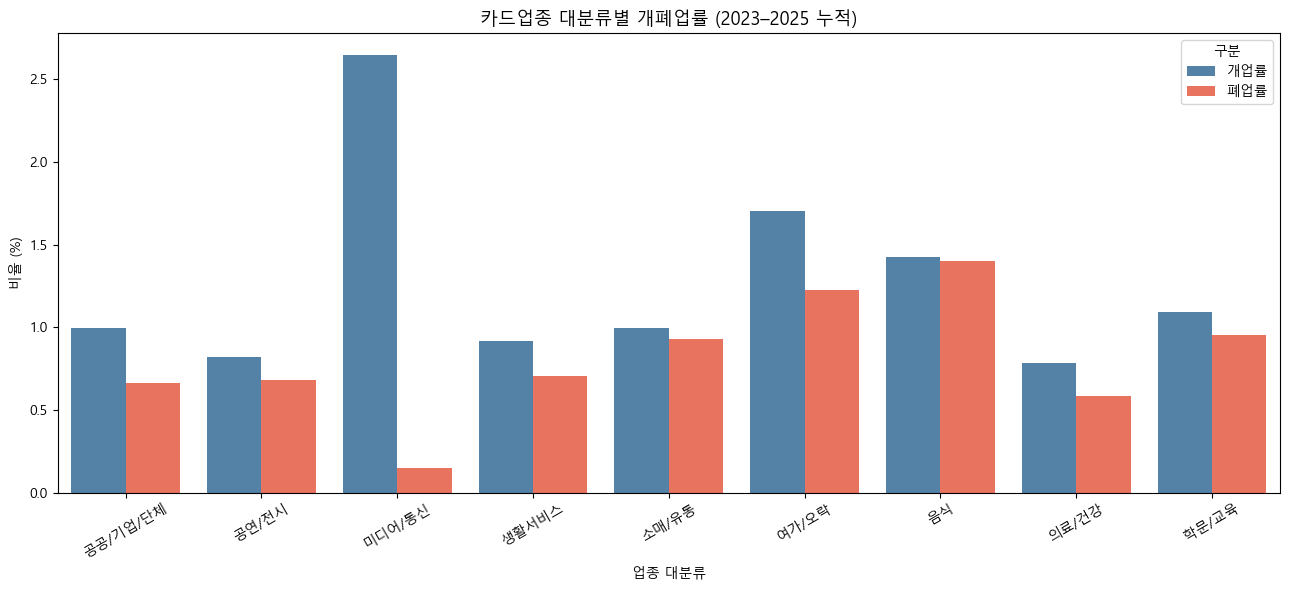

card_tpbuz_nm_1      개업률      폐업률
         미디어/통신 2.647601 0.147601
          여가/오락 1.705779 1.223666
             음식 1.425689 1.398128
          학문/교육 1.091321 0.950943
       공공/기업/단체 0.998714 0.664456
          소매/유통 0.995769 0.927060
          생활서비스 0.914707 0.703704
          공연/전시 0.819508 0.679592
          의료/건강 0.783865 0.585446


In [ ]:
# ── 카드업종 대분류별 개폐업률 ────────────────────────────
biz = (
    df_eda.groupby("card_tpbuz_nm_1")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
biz["개업률"] = biz["open_cnt"] / biz["mer_cnt"] * 100
biz["폐업률"] = biz["close_cnt"] / biz["mer_cnt"] * 100

biz_melted = biz.melt(
    id_vars="card_tpbuz_nm_1",
    value_vars=["개업률", "폐업률"],
    var_name="구분",
    value_name="비율",
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=biz_melted,
    x="card_tpbuz_nm_1",
    y="비율",
    hue="구분",
    palette={"개업률": "steelblue", "폐업률": "tomato"},
    ax=ax,
)
ax.set_title("카드업종 대분류별 개폐업률 (2023–2025 누적)", fontsize=13)
ax.set_xlabel("업종 대분류")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print(biz[["card_tpbuz_nm_1","개업률","폐업률"]].sort_values("개업률", ascending=False).to_string(index=False))

=== 원도심에서만 폐업 우위인 업종 ===
                 원도심_개업률  원도심_폐업률  원도심_순증감  분당구_순증감
card_tpbuz_nm_1                                    
공연/전시              0.661    0.859   -0.198    0.287
음식                 1.450    1.473   -0.023    0.079


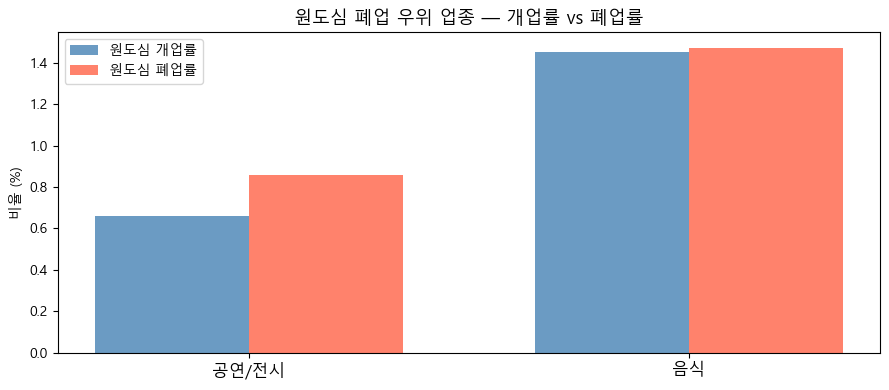

=== 원도심 vs 분당구 순증감 격차 (음수일수록 원도심 불리) ===
                 원도심_순증감  분당구_순증감     격차
card_tpbuz_nm_1                         
공연/전시             -0.198    0.287 -0.485
여가/오락              0.261    0.731 -0.471
생활서비스              0.122    0.296 -0.174
의료/건강              0.139    0.250 -0.111
음식                -0.023    0.079 -0.102
소매/유통              0.059    0.080 -0.021
학문/교육              0.142    0.140  0.002
공공/기업/단체           0.369    0.302  0.067
미디어/통신             2.748    2.441  0.306


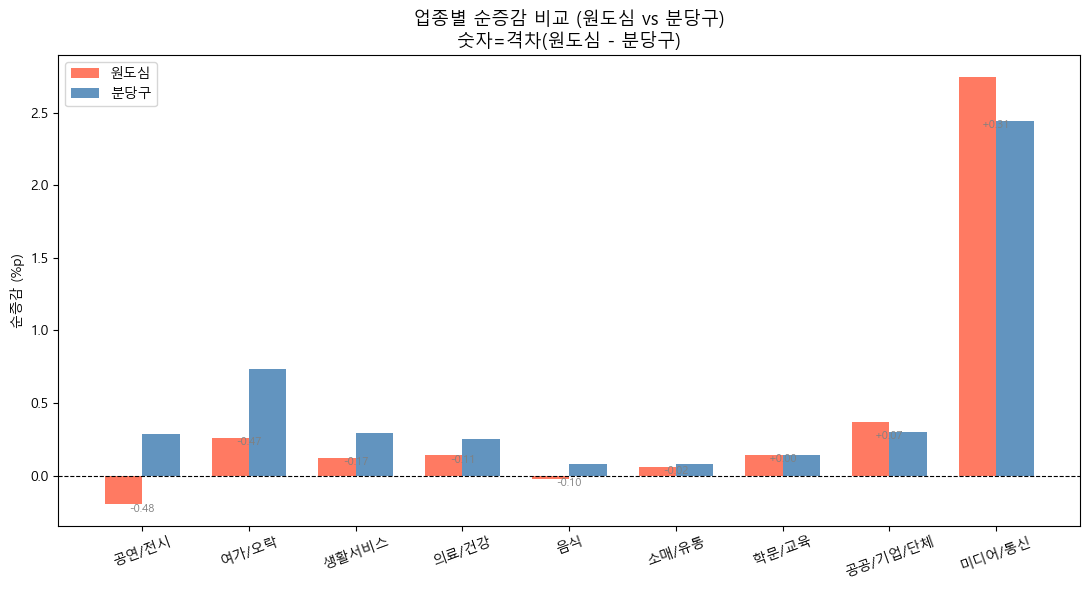

In [46]:
# ── 업종별 원도심 폐업 우위 & 원도심 vs 분당구 격차 분석 ──────────────────

# 지역별 업종 집계
def biz_stats(data):
    b = (
        data.groupby("card_tpbuz_nm_1")[["open_cnt", "close_cnt", "mer_cnt"]]
        .sum()
        .reset_index()
    )
    b["개업률"] = b["open_cnt"] / b["mer_cnt"] * 100
    b["폐업률"] = b["close_cnt"] / b["mer_cnt"] * 100
    b["순증감"] = b["개업률"] - b["폐업률"]
    return b.set_index("card_tpbuz_nm_1")

stat_원도심 = biz_stats(df_원도심)
stat_분당구 = biz_stats(df_분당구)

# 격차 테이블 (원도심 순증감 - 분당구 순증감)
gap = stat_원도심[["개업률", "폐업률", "순증감"]].copy()
gap.columns = ["원도심_개업률", "원도심_폐업률", "원도심_순증감"]
gap["분당구_순증감"] = stat_분당구["순증감"]
gap["격차"] = gap["원도심_순증감"] - gap["분당구_순증감"]
gap = gap.sort_values("격차")

# ── 2. 원도심에서만 폐업 우위인 업종 ─────────────────────────────────
neg_원도심 = gap[gap["원도심_순증감"] < 0].copy()
print("=== 원도심에서만 폐업 우위인 업종 ===")
print(neg_원도심[["원도심_개업률", "원도심_폐업률", "원도심_순증감", "분당구_순증감"]].round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(neg_원도심))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], neg_원도심["원도심_개업률"], width, label="원도심 개업률", color="steelblue", alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], neg_원도심["원도심_폐업률"], width, label="원도심 폐업률", color="tomato", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(neg_원도심.index, fontsize=12)
ax.set_title("원도심 폐업 우위 업종 — 개업률 vs 폐업률", fontsize=13)
ax.set_ylabel("비율 (%)")
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. 원도심 vs 분당구 격차 시각화 ──────────────────────────────────
print("=== 원도심 vs 분당구 순증감 격차 (음수일수록 원도심 불리) ===")
print(gap[["원도심_순증감", "분당구_순증감", "격차"]].round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
업종_list = gap.index.tolist()
x = range(len(업종_list))
ax.bar([i - width/2 for i in x], gap["원도심_순증감"], width, label="원도심", color="tomato", alpha=0.85)
ax.bar([i + width/2 for i in x], gap["분당구_순증감"], width, label="분당구", color="steelblue", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
for i, (_, row) in enumerate(gap.iterrows()):
    ax.annotate(
        f"{row['격차']:+.2f}",
        xy=(i, min(row["원도심_순증감"], row["분당구_순증감"]) - 0.05),
        ha="center", fontsize=8, color="gray",
    )
ax.set_xticks(list(x))
ax.set_xticklabels(업종_list, rotation=20, fontsize=10)
ax.set_title("""업종별 순증감 비교 (원도심 vs 분당구)
숫자=격차(원도심 - 분당구)""", fontsize=13)
ax.set_ylabel("순증감 (%p)")
ax.legend()
plt.tight_layout()
plt.show()


# 그래프 해석

- 전체 성남시에서 음식과 소매/유통업이 개업률과 폐업률이 비슷하여 상권 교체가 활발한 산업으로 판단됨
- 미디어/통신은 개업률이 압도적1위이고 폐업률은 최저를 기록함 이는 구조적인 성장을 의미
- 여가/오락은 개업률도 높지만 폐업률도 높아 불안정한 성장이 진행중
- 원도심에서만 폐업이 우위인 업종은 공연/전시와 음식임. 음식업은 원도심에서 많은 가맹점수를 보유하지만 업종 자체가 폐업률이 더 높음
- 여가·오락, 공연·전시처럼 소비 여력과 직결되는 업종에서 지역 간 양극화가 가장 두드러짐

---
## 젠트리피케이션 핵심 지표 EDA

아래 분석은 원도심 위험 진단에 직결되는 지표들입니다.

| 분석 | 지표 연결 |
|---|---|
| 원도심 vs 분당구 비교 | 양극화 구조 증명 |
| 프랜차이즈 침투율 | 상권 고급화·획일화 (중기 신호) |
| 영업 연수 집단 | 소상공인 이탈·장기 생존율 |
| 업종 다양성 지수 | 업종 획일화 탐지 (중기 신호) |
| 매출구간 E 분석 | 대형 자본 침투 (초기 신호) |

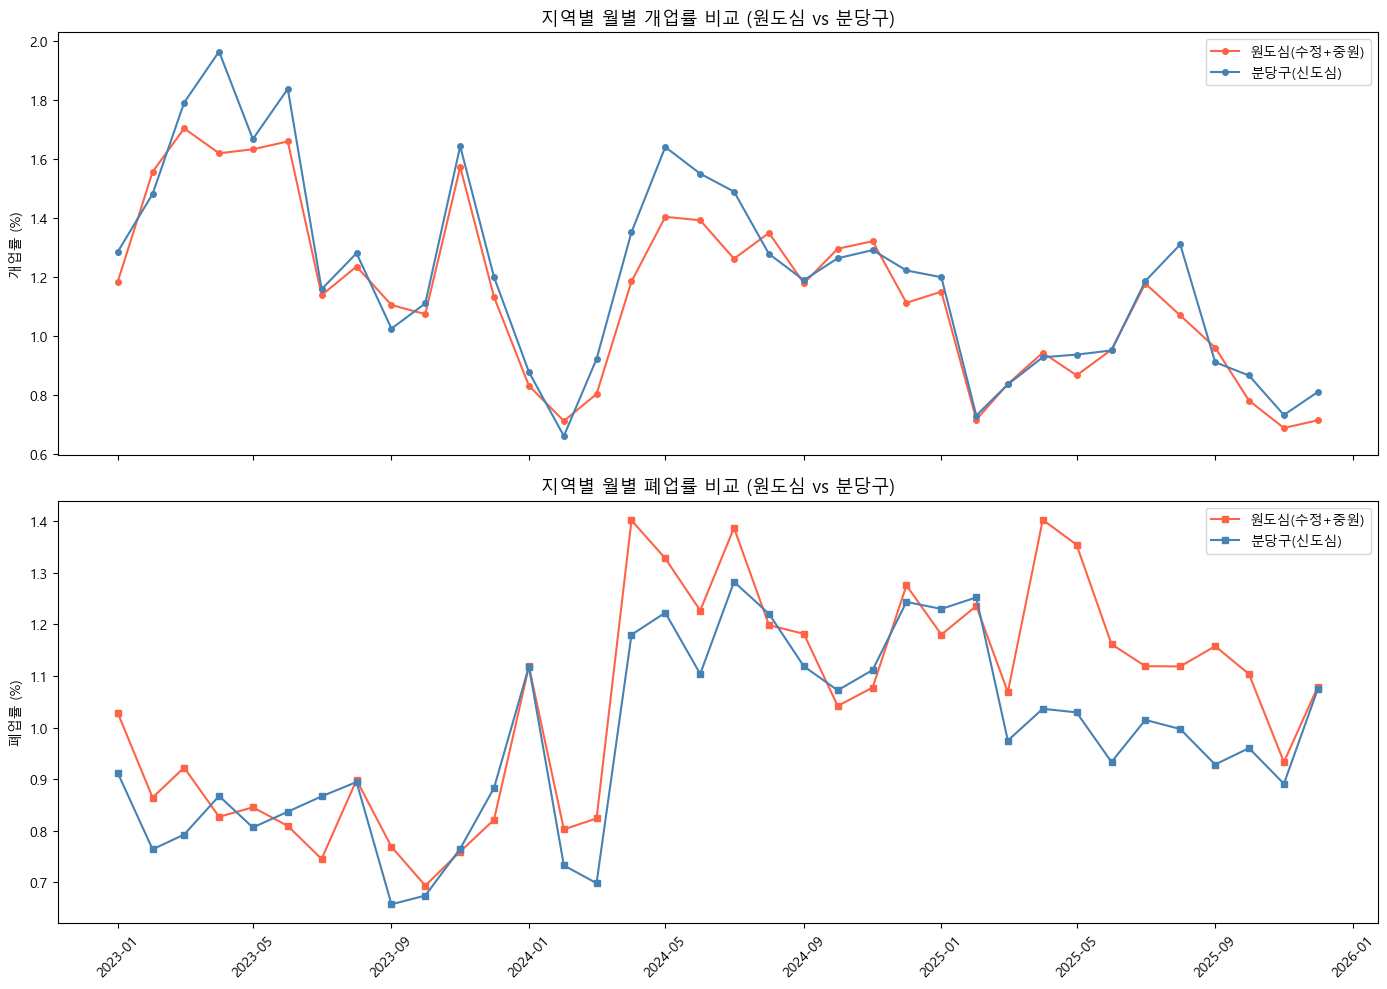

=== 연도별 개폐업률 비교 ===

[원도심(수정+중원)]
         개업률    폐업률    순증감
ta_ym                     
2023   1.384  0.831  0.553
2024   1.157  1.156  0.001
2025   0.904  1.158 -0.254

[분당구(신도심)]
         개업률    폐업률    순증감
ta_ym                     
2023   1.453  0.810  0.643
2024   1.231  1.094  0.137
2025   0.949  1.025 -0.076


In [32]:
# ── A. 원도심 vs 분당구 월별 개폐업률 비교 ──────────────────────────
regions = {
    "원도심(수정+중원)": df_원도심,
    "분당구(신도심)":    df_분당구,
}
region_colors = {"원도심(수정+중원)": "tomato", "분당구(신도심)": "steelblue"}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for region, data in regions.items():
    m = data.groupby("ta_ym")[["open_cnt", "close_cnt", "mer_cnt"]].sum().reset_index()
    m["개업률"] = m["open_cnt"] / m["mer_cnt"] * 100
    m["폐업률"] = m["close_cnt"] / m["mer_cnt"] * 100
    c = region_colors[region]
    axes[0].plot(m["ta_ym"], m["개업률"], marker="o", ms=4, label=region, color=c)
    axes[1].plot(m["ta_ym"], m["폐업률"], marker="s", ms=4, label=region, color=c)

axes[0].set_title("지역별 월별 개업률 비교 (원도심 vs 분당구)", fontsize=13)
axes[0].set_ylabel("개업률 (%)")
axes[0].legend()
axes[1].set_title("지역별 월별 폐업률 비교 (원도심 vs 분당구)", fontsize=13)
axes[1].set_ylabel("폐업률 (%)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 연도별 수치 요약
print("=== 연도별 개폐업률 비교 ===")
for region, data in regions.items():
    yr = data.groupby(data["ta_ym"].dt.year)[["open_cnt", "close_cnt", "mer_cnt"]].sum()
    yr["개업률"] = yr["open_cnt"] / yr["mer_cnt"] * 100
    yr["폐업률"] = yr["close_cnt"] / yr["mer_cnt"] * 100
    yr["순증감"] = yr["개업률"] - yr["폐업률"]
    print(f"\n[{region}]")
    print(yr[["개업률", "폐업률", "순증감"]].round(3).to_string())

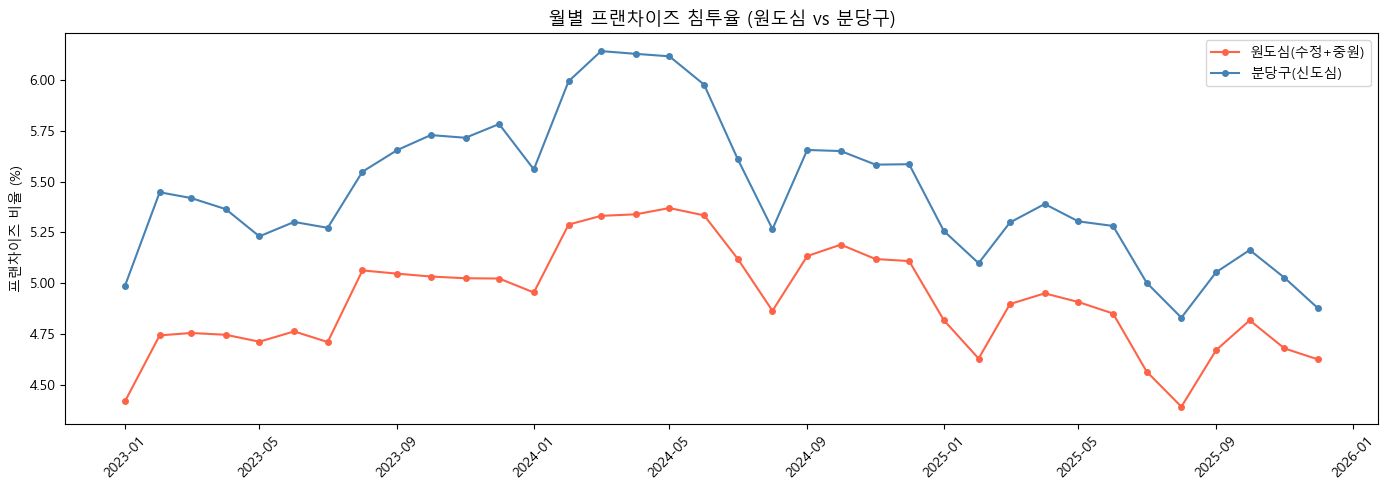

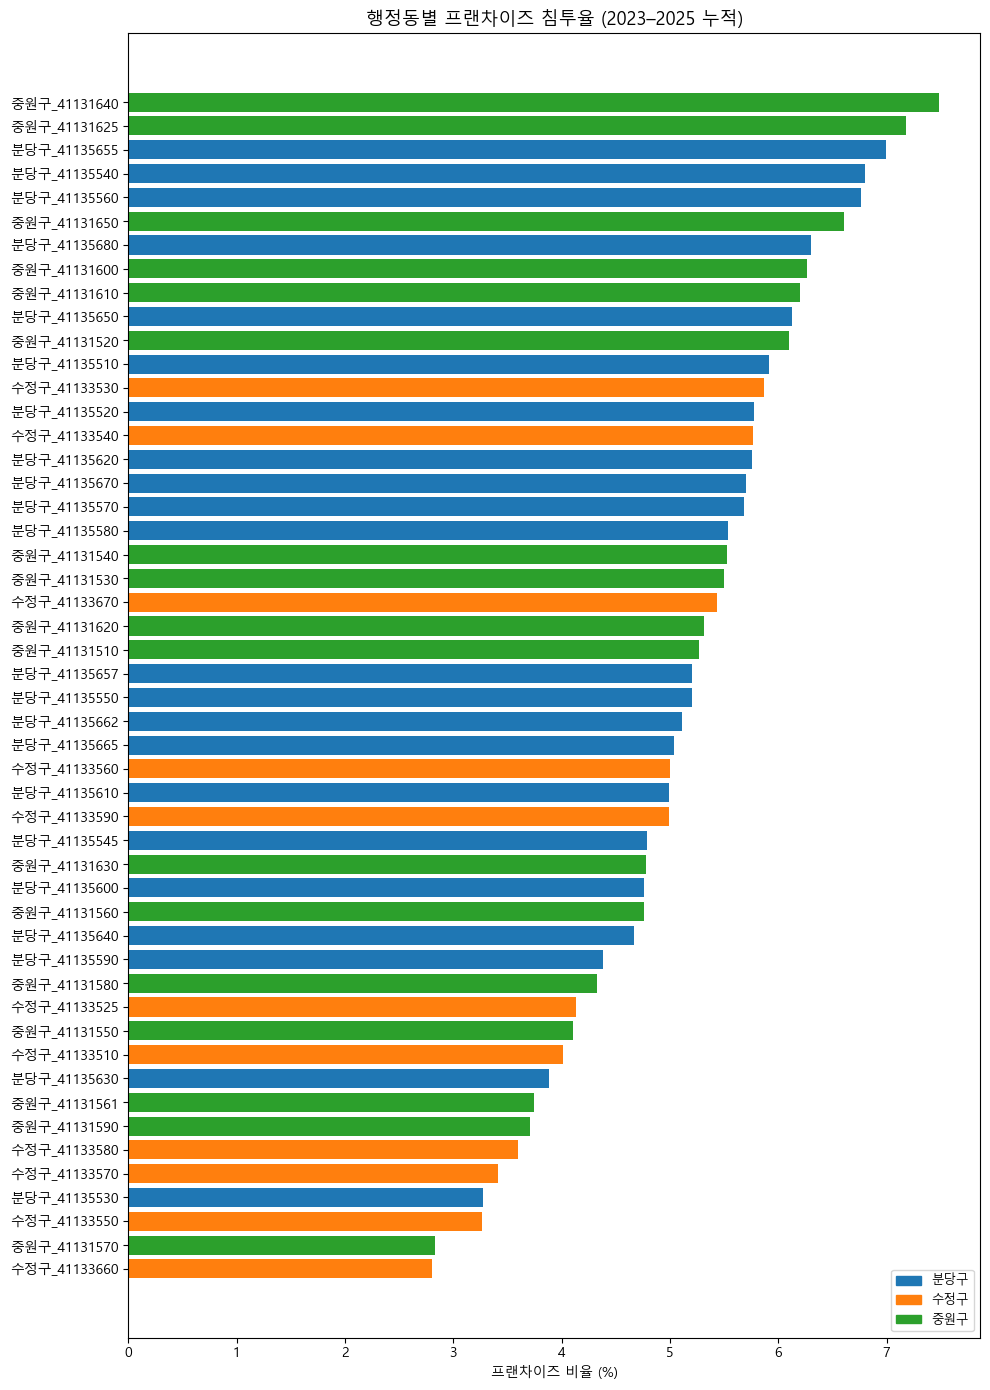

프랜차이즈 침투율 상위 10 행정동:
       구_행정동   프랜차이즈율  fran_cnt  mer_cnt
중원구_41131640 7.487810      2411    32199
중원구_41131625 7.178351     10820   150731
분당구_41135655 6.995252      8192   117108
분당구_41135540 6.798345      2251    33111
분당구_41135560 6.759322       997    14750
중원구_41131650 6.607261      2091    31647
분당구_41135680 6.302090      4794    76070
중원구_41131600 6.261950       786    12552
중원구_41131610 6.198171      1308    21103
분당구_41135650 6.124978      2817    45992


In [33]:
# ── B. 프랜차이즈 침투율 분석 ────────────────────────────────────────
# 프랜차이즈 비율 = fran_cnt / mer_cnt → 대형 자본 침투·상권 획일화 지표

# B-1. 월별 프랜차이즈 침투율 (원도심 vs 분당구)
fig, ax = plt.subplots(figsize=(14, 5))
for region, data in regions.items():
    fran_m = data.groupby("ta_ym")[["fran_cnt", "mer_cnt"]].sum().reset_index()
    fran_m["프랜차이즈율"] = fran_m["fran_cnt"] / fran_m["mer_cnt"] * 100
    ax.plot(fran_m["ta_ym"], fran_m["프랜차이즈율"], marker="o", ms=4,
            label=region, color=region_colors[region])
ax.set_title("월별 프랜차이즈 침투율 (원도심 vs 분당구)", fontsize=13)
ax.set_ylabel("프랜차이즈 비율 (%)")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# B-2. 행정동별 프랜차이즈 침투율
fran_dong = (
    df_eda.groupby("구_행정동")[["fran_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
fran_dong["프랜차이즈율"] = fran_dong["fran_cnt"] / fran_dong["mer_cnt"] * 100
fran_dong = fran_dong.sort_values("프랜차이즈율", ascending=True)
bar_c = fran_dong["구_행정동"].str.split("_").str[0].map(color_map)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(fran_dong["구_행정동"], fran_dong["프랜차이즈율"], color=bar_c.values)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=g) for g, c in color_map.items()], fontsize=9)
ax.set_title("행정동별 프랜차이즈 침투율 (2023–2025 누적)", fontsize=13)
ax.set_xlabel("프랜차이즈 비율 (%)")
plt.tight_layout()
plt.show()

print("프랜차이즈 침투율 상위 10 행정동:")
print(fran_dong.nlargest(10, "프랜차이즈율")[["구_행정동", "프랜차이즈율", "fran_cnt", "mer_cnt"]].to_string(index=False))

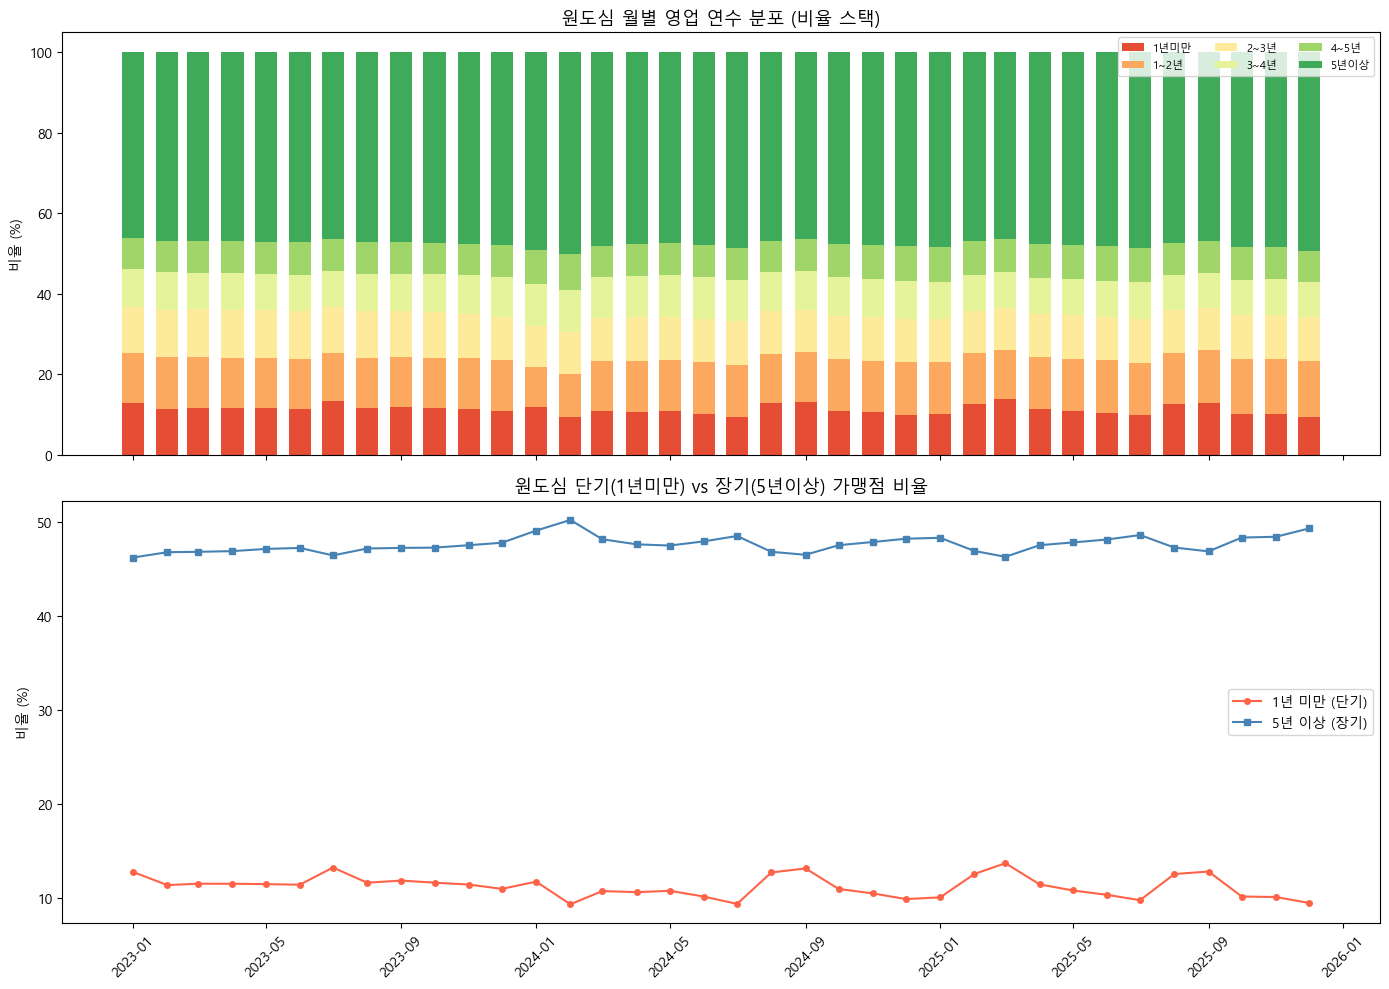

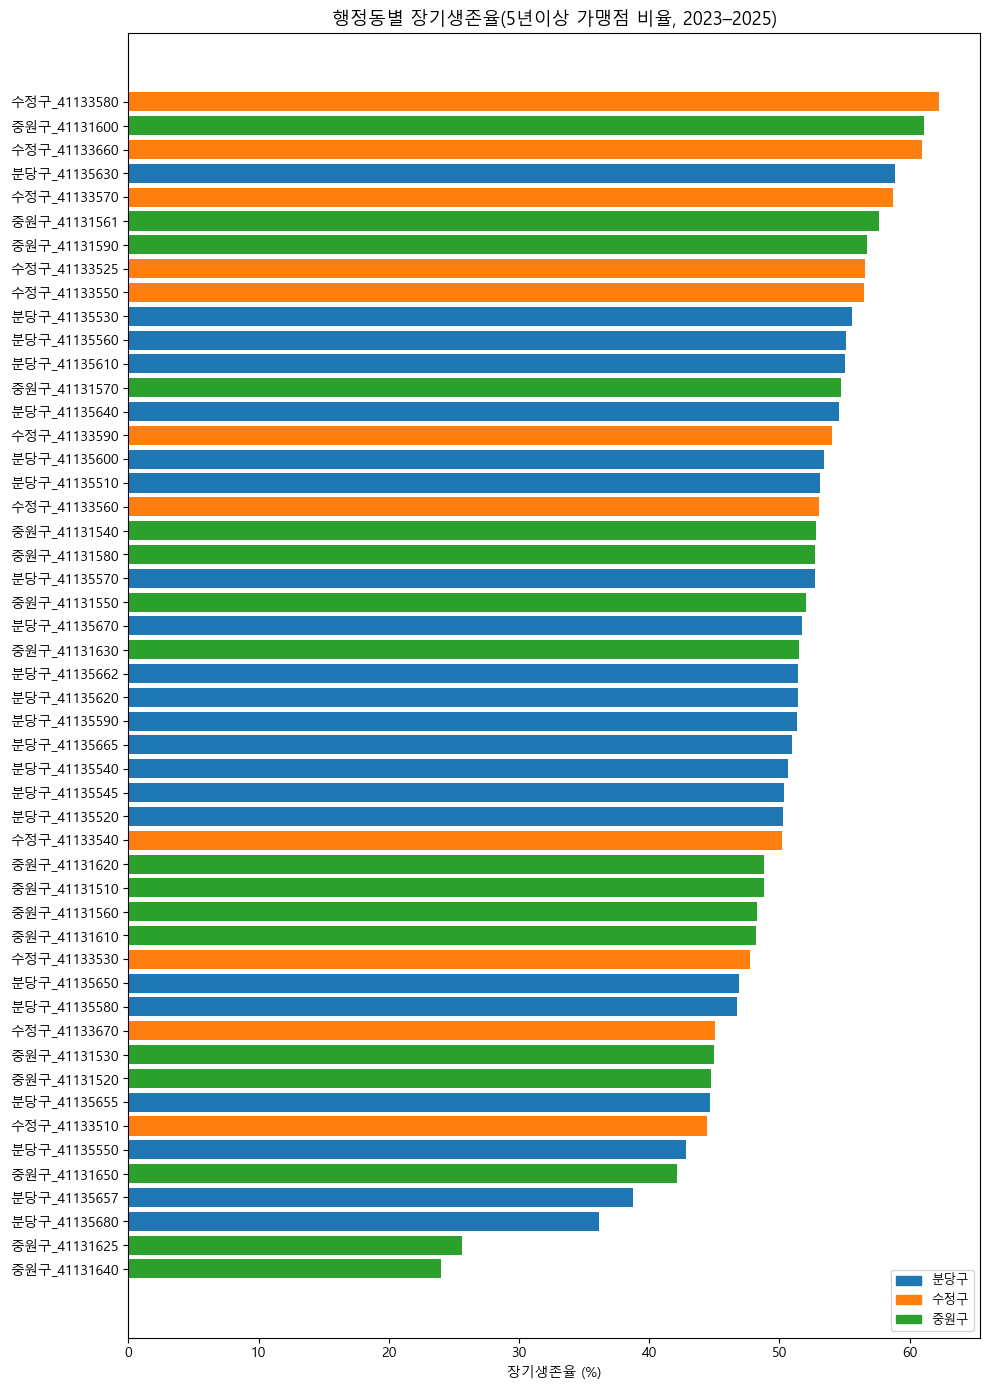

장기생존율 하위 10 행정동 (소상공인 이탈 위험):
       구_행정동  장기생존율  단기비율
중원구_41131640  24.03 16.86
중원구_41131625  25.66 15.85
분당구_41135680  36.13 14.79
분당구_41135657  38.78 14.24
중원구_41131650  42.17 13.80
분당구_41135550  42.84 12.10
수정구_41133510  44.45 12.63
분당구_41135655  44.66 12.15
중원구_41131520  44.74 12.70
중원구_41131530  44.95 11.86


In [34]:
# ── C. 영업 연수 코호트 분석 ─────────────────────────────────────────
# open_11_cnt ~ open_60_cnt → 단기 가맹점 증가 = 상권 불안정, 장기 감소 = 소상공인 이탈

cohort_cols = ["open_11_cnt", "open_12_23_cnt", "open_24_35_cnt",
               "open_36_47_cnt", "open_48_59_cnt", "open_60_cnt"]
cohort_labels = ["1년미만", "1~2년", "2~3년", "3~4년", "4~5년", "5년이상"]

# C-1. 원도심 월별 영업 연수 분포 (스택 차트)
coh_m = (
    df_원도심.groupby("ta_ym")[cohort_cols].sum().reset_index()
)
total = coh_m[cohort_cols].sum(axis=1)
coh_pct = coh_m[cohort_cols].div(total, axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
bottom = np.zeros(len(coh_m))
palette = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(cohort_cols)))
for col, label, color in zip(cohort_cols, cohort_labels, palette):
    axes[0].bar(coh_m["ta_ym"], coh_pct[col], bottom=bottom, label=label, color=color, width=20)
    bottom += coh_pct[col].values
axes[0].set_title("원도심 월별 영업 연수 분포 (비율 스택)", fontsize=13)
axes[0].set_ylabel("비율 (%)")
axes[0].legend(loc="upper right", ncol=3, fontsize=8)

# C-2. 단기(1년 미만) vs 장기(5년 이상) 비율 추이
coh_m["단기비율"] = coh_pct["open_11_cnt"]
coh_m["장기비율"] = coh_pct["open_60_cnt"]
axes[1].plot(coh_m["ta_ym"], coh_m["단기비율"], marker="o", ms=4, label="1년 미만 (단기)", color="tomato")
axes[1].plot(coh_m["ta_ym"], coh_m["장기비율"], marker="s", ms=4, label="5년 이상 (장기)", color="steelblue")
axes[1].set_title("원도심 단기(1년미만) vs 장기(5년이상) 가맹점 비율", fontsize=13)
axes[1].set_ylabel("비율 (%)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# C-3. 행정동별 장기생존율 (5년 이상 비율)
coh_dong = df_eda.groupby("구_행정동")[cohort_cols + ["mer_cnt"]].sum().reset_index()
coh_dong_total = coh_dong[cohort_cols].sum(axis=1)
coh_dong["장기생존율"] = coh_dong["open_60_cnt"] / coh_dong_total * 100
coh_dong["단기비율"]   = coh_dong["open_11_cnt"] / coh_dong_total * 100
coh_dong = coh_dong.sort_values("장기생존율", ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
bar_c2 = coh_dong["구_행정동"].str.split("_").str[0].map(color_map)
ax.barh(coh_dong["구_행정동"], coh_dong["장기생존율"], color=bar_c2.values)
ax.legend(handles=[Patch(color=c, label=g) for g, c in color_map.items()], fontsize=9)
ax.set_title("행정동별 장기생존율(5년이상 가맹점 비율, 2023–2025)", fontsize=13)
ax.set_xlabel("장기생존율 (%)")
plt.tight_layout()
plt.show()

print("장기생존율 하위 10 행정동 (소상공인 이탈 위험):")
print(coh_dong.nsmallest(10, "장기생존율")[["구_행정동", "장기생존율", "단기비율"]].round(2).to_string(index=False))

In [35]:
!pip install scipy

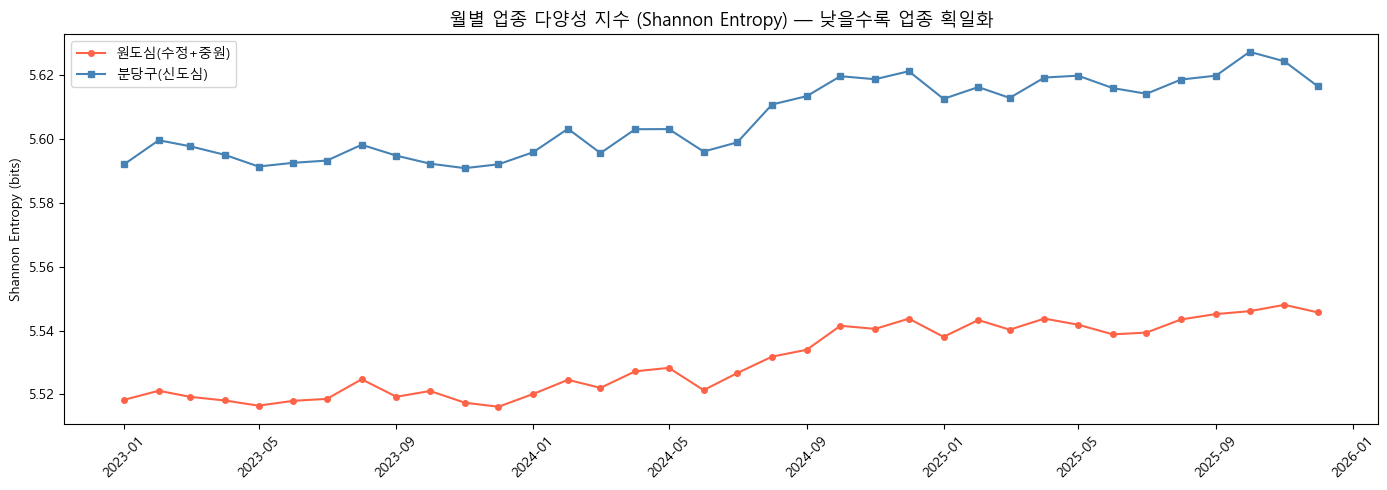

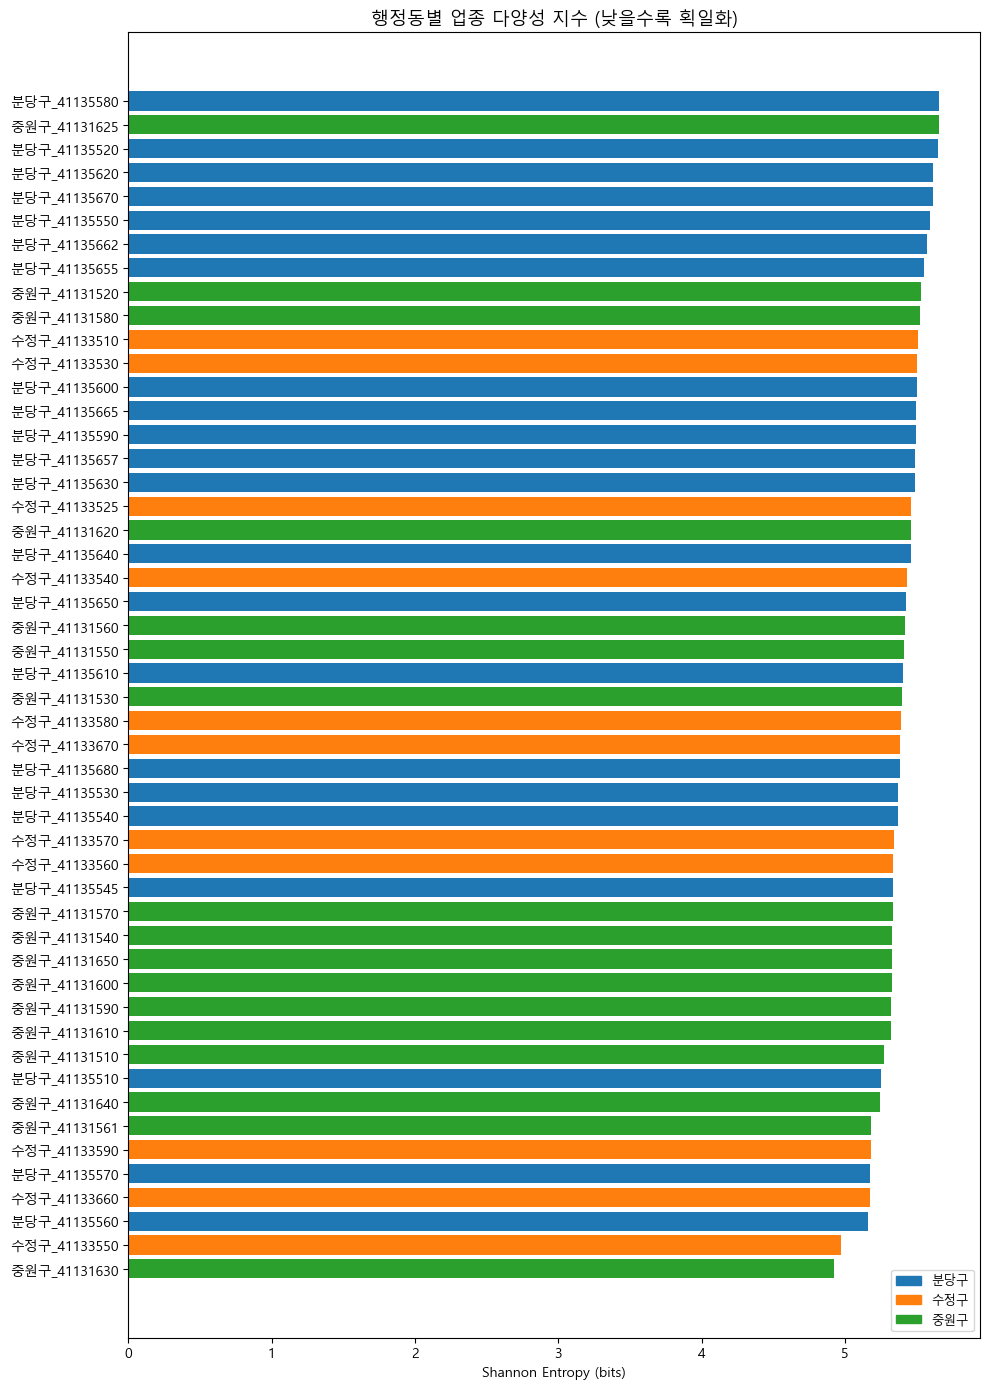

업종 다양성 하위 10 행정동 (획일화 위험):
       구_행정동    다양성지수
중원구_41131630 4.925466
수정구_41133550 4.973101
분당구_41135560 5.160003
수정구_41133660 5.176718
분당구_41135570 5.178706
수정구_41133590 5.180302
중원구_41131561 5.181296
중원구_41131640 5.241761
분당구_41135510 5.253381
중원구_41131510 5.271714


In [36]:
# ── D. 업종 다양성 지수 변화 (점포 획일화 탐지) ─────────────────────
# Shannon Entropy: 업종 구성이 고를수록 높음, 특정 업종 쏠림이면 낮아짐

from scipy.stats import entropy

def shannon_diversity(series):
    counts = series.value_counts()
    probs = counts / counts.sum()
    return entropy(probs, base=2)

# D-1. 원도심 월별 업종 다양성 지수 추이
div_m = (
    df_원도심.groupby("ta_ym")["card_tpbuz_cd"]
    .apply(shannon_diversity)
    .reset_index()
    .rename(columns={"card_tpbuz_cd": "다양성지수"})
)
div_m_bd = (
    df_분당구.groupby("ta_ym")["card_tpbuz_cd"]
    .apply(shannon_diversity)
    .reset_index()
    .rename(columns={"card_tpbuz_cd": "다양성지수"})
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(div_m["ta_ym"], div_m["다양성지수"], marker="o", ms=4, label="원도심(수정+중원)", color="tomato")
ax.plot(div_m_bd["ta_ym"], div_m_bd["다양성지수"], marker="s", ms=4, label="분당구(신도심)", color="steelblue")
ax.set_title("월별 업종 다양성 지수 (Shannon Entropy) — 낮을수록 업종 획일화", fontsize=13)
ax.set_ylabel("Shannon Entropy (bits)")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# D-2. 행정동별 업종 다양성 지수
div_dong = (
    df_eda.groupby("구_행정동")["card_tpbuz_cd"]
    .apply(shannon_diversity)
    .reset_index()
    .rename(columns={"card_tpbuz_cd": "다양성지수"})
    .sort_values("다양성지수", ascending=True)
)
bar_cd = div_dong["구_행정동"].str.split("_").str[0].map(color_map)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(div_dong["구_행정동"], div_dong["다양성지수"], color=bar_cd.values)
ax.legend(handles=[Patch(color=c, label=g) for g, c in color_map.items()], fontsize=9)
ax.set_title("행정동별 업종 다양성 지수 (낮을수록 획일화)", fontsize=13)
ax.set_xlabel("Shannon Entropy (bits)")
plt.tight_layout()
plt.show()

print("업종 다양성 하위 10 행정동 (획일화 위험):")
print(div_dong.head(10).to_string(index=False))

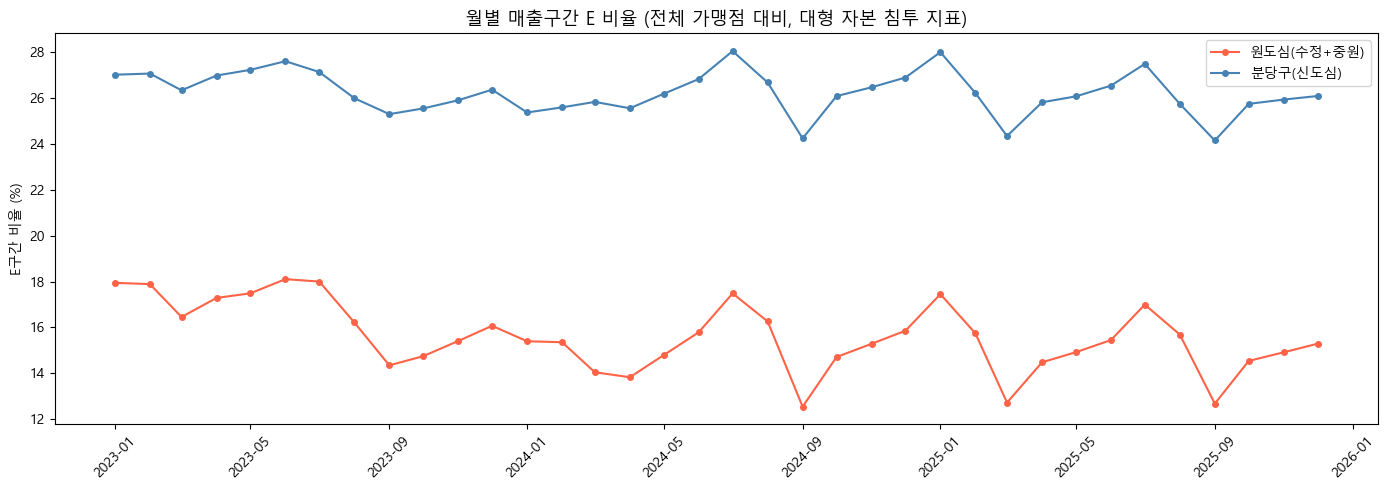

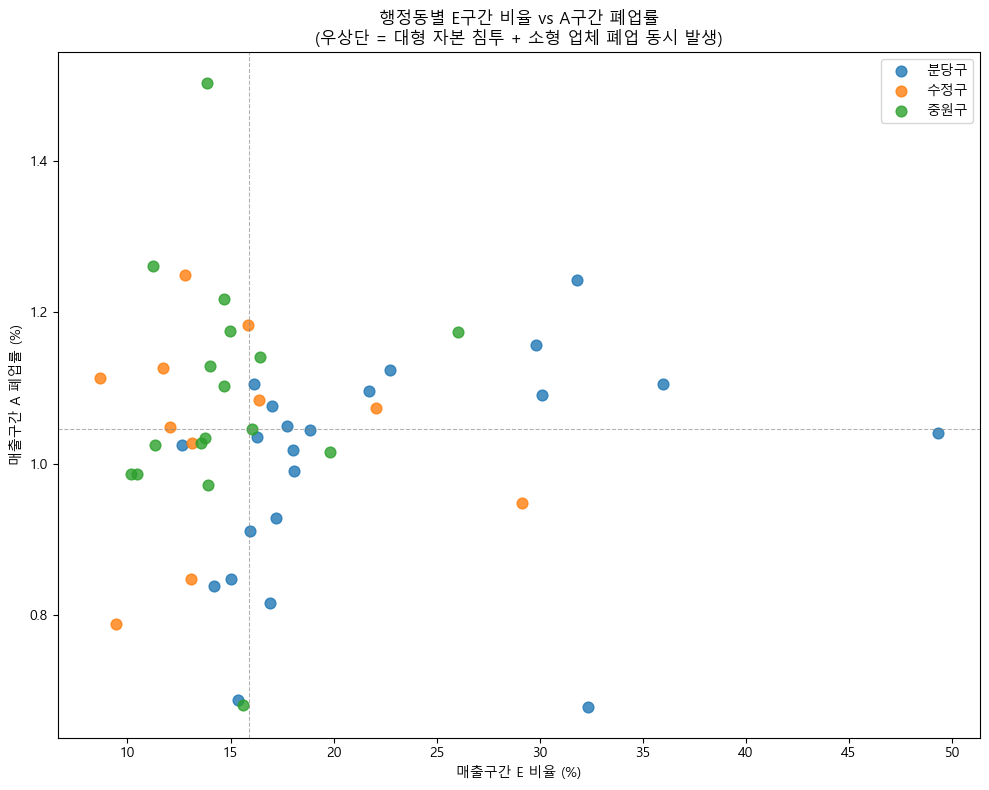

E비율 상위 10 행정동:
       구_행정동   E비율  A폐업률
분당구_41135657 49.32  1.04
분당구_41135580 36.00  1.11
분당구_41135570 32.36  0.68
분당구_41135655 31.80  1.24
분당구_41135520 30.12  1.09
분당구_41135550 29.81  1.16
수정구_41133570 29.15  0.95
중원구_41131650 26.01  1.17
분당구_41135670 22.72  1.12
수정구_41133670 22.08  1.07


In [37]:
# ── E. 매출구간 E 분석 (대형 자본 침투 지표) ────────────────────────
# E 구간(30억 초과 또는 국세청 미등록) = 대형 프랜차이즈 집중 구간
# E 비율 증가 + A구간 폐업 동시 발생 → 젠트리피케이션 초기 패턴

df_all = df.copy()
df_all["ta_ym"] = pd.to_datetime(df_all["ta_ym"])
df_all["구명"] = df_all["cty_rgn_no"].astype(str).map(gu_map)
df_all["구_행정동"] = df_all["구명"] + "_" + df_all["admi_cty_no"].astype(str)

# E-1. 월별 E구간 비율 (원도심 vs 분당구)
fig, ax = plt.subplots(figsize=(14, 5))
for region_label, rgn_codes in [("원도심(수정+중원)", ["41133", "41131"]), ("분당구(신도심)", ["41135"])]:
    sub = df_all[df_all["cty_rgn_no"].astype(str).isin(rgn_codes)]
    e_m = sub.groupby("ta_ym")[["mer_cnt"]].sum().reset_index()
    e_m["E_cnt"] = sub[sub["sale"] == "E"].groupby("ta_ym")["mer_cnt"].sum().values
    e_m["E비율"] = e_m["E_cnt"] / (e_m["mer_cnt"]) * 100
    c = region_colors[region_label]
    ax.plot(e_m["ta_ym"], e_m["E비율"], marker="o", ms=4, label=region_label, color=c)
ax.set_title("월별 매출구간 E 비율 (전체 가맹점 대비, 대형 자본 침투 지표)", fontsize=13)
ax.set_ylabel("E구간 비율 (%)")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# E-2. 행정동별 E 비율 vs A 폐업률 산점도 (동시 발생 패턴)
e_dong = df_all.groupby("구_행정동")["mer_cnt"].sum().reset_index().rename(columns={"mer_cnt": "전체"})
e_only = df_all[df_all["sale"] == "E"].groupby("구_행정동")["mer_cnt"].sum().reset_index().rename(columns={"mer_cnt": "E_cnt"})
a_close = df_all[df_all["sale"] == "A"].groupby("구_행정동")[["close_cnt", "mer_cnt"]].sum().reset_index()
a_close["A폐업률"] = a_close["close_cnt"] / a_close["mer_cnt"] * 100

scatter = e_dong.merge(e_only, on="구_행정동", how="left").merge(a_close[["구_행정동", "A폐업률"]], on="구_행정동", how="left")
scatter["E비율"] = scatter["E_cnt"] / scatter["전체"] * 100
scatter = scatter.dropna()
scatter["구명"] = scatter["구_행정동"].str.split("_").str[0]

fig, ax = plt.subplots(figsize=(10, 8))
for gu, grp in scatter.groupby("구명"):
    ax.scatter(grp["E비율"], grp["A폐업률"], label=gu, color=color_map.get(gu, "gray"), s=60, alpha=0.8)
ax.set_title("행정동별 E구간 비율 vs A구간 폐업률\n(우상단 = 대형 자본 침투 + 소형 업체 폐업 동시 발생)", fontsize=12)
ax.set_xlabel("매출구간 E 비율 (%)")
ax.set_ylabel("매출구간 A 폐업률 (%)")
ax.legend()
ax.axhline(scatter["A폐업률"].median(), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(scatter["E비율"].median(), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

print("E비율 상위 10 행정동:")
print(scatter.nlargest(10, "E비율")[["구_행정동", "E비율", "A폐업률"]].round(2).to_string(index=False))